<!-- student -->
# Practicum 1 — The Cost of Closing a Failed Bank

**Kang, Lowery & Wardlaw (2015), Review of Financial Studies 28(4): 1060–1102.**

The FDIC (Federal Deposit Insurance Corporation) decides when to close a troubled bank. The cost of closing is never recorded — only the decisions are. This notebook recovers the cost function that would make a forward-looking regulator behave the way the FDIC actually behaved.

In this practicum we will:

1. disucss the model on FDIC's decision;
2. estimate the parameters on cost of closing a failed bank;
3. run counterfactuals based on estimates.


---
### 0.1  Setup and configuration

In [1]:
# === 0.1a  SETUP — run me first ===
#
# Two things to locate, and they come from different places:
#     klw.py     the toolkit you are GIVEN — on Kaggle, always fetched from GitHub, so you
#                get the current one.  Notebook options -> Internet must be ON.
#     data/      the panels — the competition dataset attached under /kaggle/input.
# Running locally instead, a copy of klw.py next to the notebook wins over the download.

import json, os, sys, time, warnings

import numpy as np                 # linear algebra
import pandas as pd                # data processing, CSV / parquet I/O
import matplotlib.pyplot as plt    # the §2.3 calibration figure
from scipy.special import expit    # the logistic function (§3)
from sklearn.linear_model import LogisticRegression      # the §2.3 and §3 CCP logits

warnings.filterwarnings("ignore")      # the solvers emit benign overflow warnings
np.seterr(all="ignore")                # on the way to a correct answer

ON_KAGGLE = os.path.isdir("/kaggle/input")
OUT_DIR   = "/kaggle/working" if ON_KAGGLE else os.getcwd()   # where a fetched klw.py lands
os.makedirs(OUT_DIR, exist_ok=True)

KLW_URL = ("https://raw.githubusercontent.com/mhnam/dse2026-practicum/main/"
           "practicum1-bank-closure/src/klw.py")


def find_toolkit(fname="klw.py"):
    """Where klw.py is — returns (directory, how it was found).

    On Kaggle it is downloaded from GitHub every run: the competition dataset carries the
    panels, not the code, and the download is the copy guaranteed to match this notebook.
    Running locally, a copy next to the notebook wins, so an edited toolkit is picked up
    without a round trip.
    """
    if not ON_KAGGLE:
        here = os.environ.get("DSE2026_ROOT") or os.getcwd()
        for _ in range(4):                   # the answer key sits two levels down
            for sub in ("src", ""):
                if os.path.isfile(os.path.join(here, sub, fname)):
                    return os.path.join(here, sub), "local"
            here = os.path.dirname(here)
    try:
        import urllib.request
        urllib.request.urlretrieve(KLW_URL, os.path.join(OUT_DIR, fname))
        return OUT_DIR, "github"
    except Exception as exc:
        raise FileNotFoundError(
            f"could not download {fname} from {KLW_URL}.  On Kaggle: open the right-hand "
            "panel, Notebook options -> Internet, and switch it ON, then re-run this cell.  "
            f"Running locally: put the practicum's src/ folder next to this notebook.  "
            f"Last error: {exc}")


_kdir, _via = find_toolkit()
sys.path.insert(0, _kdir)
sys.modules.pop("klw", None)   # so re-running this cell picks up the current klw.py,
                               # not a copy Jupyter imported earlier this session
# Imported BY NAME, not as a namespace: the notebook reads `Tobit.from_frame(...)`, exactly
# as it would if the class were defined here.  This list is the toolkit's whole surface.
from klw import (find_data_dir, download_data, load_real_data, load_sim_data,  # the bundle
                 calendar_seq, add_calendar_lags, bspline_basis,         # panel construction
                 Estimates, Tobit, expected_y, PanelVAR, gmm_fit,        # the estimators
                 Result, reference_model, counterfactual,                # §3, the solver
                 SCENARIOS)

# The panels: the attached competition folder if it has them, downloaded from GitHub if not.
# Kaggle mounts data through symlinked directories, so "attached" is not always "visible" --
# download=True means a mount this cannot see costs you 20 MB, not an error.
DATA_DIR = find_data_dir(download=True)
SUPPORT_FILES = ("klw_first_stage.npz", "dataforparam_KLW.csv")
if any(not os.path.isfile(os.path.join(DATA_DIR, name)) for name in SUPPORT_FILES):
    # `find_data_dir` stops once it sees the parquet marker.  An attached
    # parquet-only bundle therefore still needs the two §2 support files.
    DATA_DIR = download_data(dest=DATA_DIR)
PARAM_PATH = os.path.join(DATA_DIR, "dataforparam_KLW.csv")

print(f"toolkit: klw.py ({_via})")
print(f"data   : {DATA_DIR}")

toolkit: klw.py (local)
data   : /Users/bc3139/repo/summer2026/DSE2026/practicum/practicum1/data


In [2]:
# === 0.1b  the paper's published constants ===
# beta is CALIBRATED, not estimated: it is only weakly identified from CCPs (in KLW's own
# code it moves <0.005 from its seed), so we fix it at the authors' value and never search it.
PAPER_BETA = 0.9582338276565384       # §2, the real Call Report panel

# NOT the same float, and not a typo.  The SIMULATED panels of §3 were generated at the
# ROUNDED 0.9582, so §3's moment has to use the rounded value or §3.2's recovered sigma no
# longer matches the DGP the panel came from.  Two names on purpose.
PAPER_BETA_SIM = 0.9582               # §3, the simulated panels

In [3]:
# === 0.1c  CONFIGURATION — the only tunable cell ===
class CFG:
    SEED       = 42              # forward-simulation draws (§2.4)
    R_FORWARD  = 5000            # Monte-Carlo draws per row in forward simulation (§2.4)
    CF_SEED    = 7               # counterfactual draws (§3.2)
    SEED_SWEEP = (0, 1, 7)       # counterfactual seeds compared in §3.3 (each
                                 # costs a full fixed-point solve per scenario)

### 0.2  Data: sources, variables, and sample selection

**Sources.**
1. Bank financials and realised resolution costs are FDIC records matched to
quarterly **Call Reports**, supplying asset size, the equity ratio, non-performing loans, real estate owned, net income and core deposits.
2. Congressional banking-committee representation is
from **Nelson (2011)** and **Stewart III & Woon (2011)**.
3. State unemployment is **FRED** (Federal Reserve Bank of St. Louis).

**Unit of observation.**
One row is a **bank-quarter**: bank $i$ in quarter $t$. `failed = 1` is terminal — the bank
leaves the panel after it, and `estimated_cost` is recorded on that last row and nowhere else.

**Sample**: 1984Q4–1992Q4

1. assets of at least \$10M and an equity/assets ratio below 30%, excluding very small and
   effectively unlevered banks;
2. assets below \$3B, excluding the very largest;
3. bank-quarters with one-year asset growth above 150% dropped, as scale-altering mergers or
   data errors;
4. ROA < 0 — the *distressed* population, i.e. banks the FDIC might plausibly have closed.

**Variables.** For a given bank $i$ at time $t$:

| Theory                        | Data                          |
|-------------------------------|-------------------------------|
| Log assets                    | `log_assets`                  |
| Assets, \$thousands           | `assets`                      |
| Equity / assets               | `equity_a`                    |
| Non-performing loans / assets | `npf_a`                       |
| Real estate owned / assets    | `realest_a`                   |
| Return on assets, annualised  | `roa`                         |
| 1-year asset growth           | `asset_growth_1y`             |
| State unemployment            | `unemp`                       |
| Congressional oversight       | `house`, `senate`             |
| Resolution cost               | `estimated_cost` (÷ `assets`) |
| Closure                       | `failed`                      |

`assets` and `estimated_cost` are in **\$thousands**, so $MC$, $\sigma$ and $\theta$ inherit
those units throughout. The panel also carries some near-duplicate columns (`roa_qtr`,
`asset_growth_2y`, `unemp_nat`) that are **not** the ones above — picking one fails a check
rather than silently producing a wrong number.

In [4]:
# === 0.2  load the real Call Report panel ===
# `yearq` is coded YYYYQ, which is not a period that advances by 1 (19844 -> 19851 is a jump
# of 7).  Both §2.2 and §2.3 need one that does; `calendar_seq` from the toolkit decodes it.
df = load_real_data()
df.head()

,rssd_id,yearq,failed,estimated_cost,assets,log_assets,equity,equity_a,net_income,net_income_annual,...,asset_growth_1y,asset_growth_2y,core_dep_a,log_county_dep,us_equity_a,unemp,unemp_nat,house,senate,state
0,64,19874,0,NaN,1.252007e+05,11.737673,6909.812428,0.055190,-465.435699,-91.561119,...,0.090418,0.338305,0.267824,12.432881,0.061149,7.4,5.7,5.0,2.0,48.0
1,64,19881,0,NaN,1.031483e+05,11.543922,6797.541845,0.065901,-56.002907,-320.881500,...,-0.087035,0.095766,0.267824,12.432881,0.061685,7.7,5.7,5.0,2.0,48.0
2,64,19882,1,30384.626185,1.189686e+05,11.686615,6666.766334,0.056038,-65.977898,-514.327698,...,0.190775,0.164191,0.267824,12.432881,0.062519,7.9,5.4,5.0,2.0,48.0
3,130,19844,0,NaN,1.139717e+06,13.946291,54548.912456,0.047862,-7804.515137,-5783.511230,...,0.637258,1.623120,0.245232,15.511651,0.060704,6.0,7.3,5.0,2.0,12.0
4,130,19851,0,NaN,1.188761e+06,13.988422,53091.466824,0.044661,-858.741150,-6209.107422,...,0.625342,1.627818,0.245232,15.511651,0.062206,5.9,7.2,3.0,1.0,12.0


---
## 1  Model and identification

### 1.1  Model

#### Static payoff

Each quarter the FDIC observes a troubled bank's state $x_{it}$ and chooses
$d_{it}\in\{0,1\}$ — continue ($d=0$) or close ($d=1$). Flow payoffs are

$$\begin{cases}u_0(x_{it}) = \varepsilon_{0it}; & \\
 u_1(x_{it}) = -c(x_{it}) + \varepsilon_{1it} \end{cases}$$

- $\varepsilon_{0it},\varepsilon_{1it}$ — i.i.d. Type-1 extreme value (T1EV) of scale $\sigma$,
  independent of $x_{it}$

$c(x_{it})$, the cost of closing a bank:

$$c(x_{it}) \;=\; \underbrace{MC(x_{it}; \theta_{mc})}_{\text{monetary}} \;-\; \underbrace{\tilde x_{it}'\theta}_{\text{non-monetary}}$$

- $MC(x)$ — the resolution cost the insurance fund pays, observed **only** for banks actually closed
- $-\tilde x'\theta$ — the non-monetary cost: political forbearance, community disruption,
  supervisory reputation.

#### The FDIC's problem

$$V(x_{i,t}) \;=\; \max_{d_{i,t}\in \{0,1\}} u_{d_{i,t}}(x_{i,t}) + \beta \mathbb{E} \big[V(x_{i,t+1}) \mid x_{i,t},\, d_{i,t}\big].$$

<details>
<summary>▸ Why $\beta$ is calibrated, not estimated</summary>

$\beta$ is fixed at `PAPER_BETA` $= 0.95823$. It is only weakly identified from CCPs — the
objective barely moves with $\beta$ relative to first-stage noise — and KLW fix it by hand in
their own code, so we do the same.

</details>


### 1.2  Estimation framework

#### Identification Assumptions

1. The probability of entering the disorderly failure state from any state observed in the data is vanishingly small.
2. The error term on monetary costs is orthogonal to the choice-specific error terms.
3. The choice-specific error terms are both i.i.d. draws from a type-I extreme value distribution with location parameter $\mu$ and scale parameter $\sigma$.

#### Estimation framework

Recall, FDIC is maximizing:

$$V(x_{i,t}) \;=\; \max_{d_{i,t}\in \{0,1\}} u_{d_{i,t}}(x_{i,t}) + \beta \mathbb{E} \big[V(x_{i,t+1}) \mid x_{i,t},\, d_{i,t}\big].$$

Let the **choice-specific value functions** $V_0$ and $V_1$ be:

$$
\begin{cases}
V_0(x_{i,t}) = \varepsilon_{0,i,t} + \underbrace{\beta \mathbb{E}\big[ p_0^{(1)}(x_{0,i,t}) V_0^{(1)}(x_{0,i,t}) + p_1^{(1)} V_1^{(1)}(x_{0,i,t})\big]}_{v_0(x_{i,t})} &\\
V_1(x_{i,t}) = \varepsilon_{1,i,t} + \underbrace{-c(x_{i,t})}_{v_1(x_{i,t})}&
\end{cases}
$$

where
- $$p_1(x_{i,t}) = Pr\big[\text{FDIC closes a bank }i\text{ at time }t\big]$$
- $$p_1^{(1)}(x_{i,t}) = Pr\big[\text{FDIC closes a bank }i\text{ at time }t+1 \mid \text{bank }i\text{ not closed at time }t\big]$$

By identifying assumption 3 and using **Hotz–Miller inversion** (Hotz & Miller, 1993) we have:
$$\begin{equation}
v_0(x_{it}) - v_1(x_{it}) \;=\; \sigma \log \frac{p_0(x)}{p_1(x)}
\end{equation}$$

Also we can show that:
$$\begin{equation}
v_0(x_{it}) - v_1(x_{it}) \;=\; \beta \mathbb{E}\big[-\sigma \log p_1^{(1)}(x_{0it}) - c^{(1)}(x_{0it})\big] + c(x_{it})\end{equation}$$

By combining RHS of above two equations gives us the following:
$$\begin{equation}
\boxed{\;\sigma \log \frac{p_0(x_{it})}{p_1(x_{it})} \;=\; \beta \mathbb{E}\big[-\sigma \log p_1^{(1)}(x_{0it}) - c^{(1)}(x_{0it})\big] + c(x_{it})\;}\end{equation}$$

Notice the expression contains only:
1. observable data ($x_{i,t}$);
2. pre-estimated quantities ($p_1(x_{it})$ and monetary cost $\theta_{mc}$); and
3. structural parameters ($\sigma$ and non-monetary cost $\theta_{nmc}$)

<details>
<summary>▸ The three lines</summary>

1. Under T1EV the ex-ante value is the log-sum $\bar V(x) = \sigma \log\big[e^{v_0(x)/\sigma} + e^{v_1(x)/\sigma}\big]$ (up to the Euler constant $\sigma\gamma$, absorbed into the NMC intercept)
2. Dividing that by the expression for $p_1(x)$ above leaves $\bar V(x) = v_1(x) - \sigma \log p_1(x)$
3. Closure is terminal, so $v_1(x) = -c(x)$

</details>


### 1.3  Estimation strategy

#### STEP 1: Recover pre-estimated quantities
Step 1-1 **Monetary cost parameters** $\theta_{mc}$ using Tobit

$$y = x'b + e, \qquad e \sim N(0,\ s^{2}), \qquad y = \max(0,\ y^{*})$$

where:
- $y$ — resolution cost / assets
- $x$ — bank observable and other characteristics including `log_assets`, `equity_a`, `npf_a`, `realest_a`, `roa`, `unemp`

Step 1-2 **Transition probabilities** $f(x'\mid x)$ using VAR(4)

$$x_{k,\,t+1} \;=\; a_k \;+\; \sum_{j=1}^{7}\ \sum_{\ell=0}^{3} \rho_{k j \ell}\, x_{j,\,t-\ell} \;+\; u_{k,\,t+1}, \qquad k = 1,\dots,6$$

Step 1-3 **Conditional Choice Probabilities** $p_1(x)$ using flexible logit

$$p_1(x) \;=\; \frac{1}{1 + \exp\!\big(-[\,\Psi(x)'\gamma + c_0\,]\big)}$$

- $\Psi(x)$ — a **basis expansion** of the state: 78 columns built from $x$, laid out below
- $\gamma,\ c_0$ — logit coefficients and intercept, by maximum likelihood

#### STEP 2: Estimate structural parameters

Step 2-1 **Forward simulation**: Using the estimates from the previous step, take expectations

Step 2-2 **GMM**


---
## 2  Estimation

In [5]:
# === 2.0  supplied first-stage inputs ===
MCV  = ["log_assets", "equity_a", "npf_a", "realest_a", "roa", "unemp"]
B_MC = np.array([0.0758295, -0.0307805, -0.9750829, 1.6142688,
                 1.3772347, -0.9223462, 0.0138817])      # const first, then MCV order
S_MC = 0.1605512                                          # published Table 3, Model I

POOLS = dict(np.load(os.path.join(DATA_DIR, "klw_first_stage.npz")))

if not os.path.exists(PARAM_PATH):     # the one file the student bundle may not ship
    raise FileNotFoundError("dataforparam_KLW.csv not found - it is needed by §2; "
                            "§3, the graded section, runs without it.")
# 22,269 rows, one per bank-quarter of the §2.3 sample, in the authors' own row order.
_param = pd.read_csv(PARAM_PATH)
_EXK = {"log_assets": "Elogasset_next", "equity_a": "Eequity_a_next",
        "npf_a": "Enpf_a_next", "realest_a": "Erealest_a_next", "roa": "Eroa_next",
        "asset_growth_1y": "Egrow_a_next", "assets": "Easset_next", "unemp": "Eunemp_next"}
EX = {v: _param[k].to_numpy(float) for v, k in _EXK.items()}
HN = _param["House_next"].to_numpy(float)
SN = _param["Senate_next"].to_numpy(float)

# one bundle, so 3.4 and 3.5 take a single `supplied` argument instead of seven
SUPPLIED = dict(MCV=MCV, B_MC=B_MC, S_MC=S_MC, POOLS=POOLS, EX=EX, HN=HN, SN=SN)
print("pools:", {k: len(v) for k, v in POOLS.items()})
print("SUPPLIED keys:", sorted(SUPPLIED))

pools: {'log_assets': 39870, 'equity_a': 39870, 'npf_a': 39870, 'realest_a': 39870, 'roa': 39870, 'asset_growth_1y': 39870, 'assets': 39913, 'unemp': 1471}
SUPPLIED keys: ['B_MC', 'EX', 'HN', 'MCV', 'POOLS', 'SN', 'S_MC']


---
### 2.1  Step 1-1 — Monetary cost $\theta_{mc}$ (Tobit)

**Object.** $MC(x)$ — what the insurance fund pays to resolve a bank in state $x$.

$$y^{*} = x'b + e, \qquad e \sim N(0,\ s^{2}), \qquad y = \max(0,\ y^{*})$$

where:

- **dependent variable** $y$ — `estimated_cost / assets`. A **ratio**, not a dollar cost.
- **independent variables** $x$ — a constant plus `log_assets`, `equity_a`, `npf_a`,
  `realest_a`, `roa`.
- $b,\ s$ — coefficients and residual scale, by maximum likelihood.

**Your job** is the four modelling choices, not the likelihood: the sample (`failed == 1`), the
outcome (`estimated_cost/assets`, clipped at 0), the censoring point (`left=0.0`), the design
(the six financials above). Then `Tobit.from_frame(...).fit()`.

`dE/dx` in the output is rescaled by mean assets, which turns the ratio's slope into \$thousands.

**Compare with KLW Table 3, Model I:**

![KLW Table 3](https://raw.githubusercontent.com/mhnam/dse2026-practicum/main/practicum1-bank-closure/docs/table3.png)

<details>
<summary>Why Tobit, not OLS?</summary>
Not the censoring bias — 16 of 842 is 1.9%. The binding reason is what
§2.4 does with the fit: it evaluates $\mathbb{E}[y\mid x]$ at states where **no bank was ever
resolved**. Only the latent-normal structure extrapolates there, and only it prices the chance
of landing *on* the zero corner:

$$\mathbb{E}[y \mid x] = \Phi\!\left(\tfrac{x'b}{s}\right)x'b \;+\; s\,\phi\!\left(\tfrac{x'b}{s}\right)
\qquad \text{Wooldridge (2010), eq. 17.14}$$
</details>

<details>
<summary>What this replicates?</summary> Signs only. Our 842 resolved banks cannot reproduce
magnitudes estimated on the paper's 3,678 observations, which include premium-paying mergers
we never observe — the authors' estimation file is missing from their replication package.
The six signs are the part that carries into the second stage.

</details>

In [6]:
# === 2.1  what the Tobit is fitted on: sample, outcome, design ===
COST_COVAR   = ["log_assets", "equity_a", "npf_a", "realest_a", "roa"]
COST_THRESHOLD   = 0.0                       # resolution cost is censored below at zero
COST_LABELS = {"log_assets": "Log(assets)", "equity_a": "Equity/assets",
             "npf_a": "NP loans/assets", "realest_a": "RE owned/assets",
             "roa": "Net income/assets", "const": "Constant"}
print(f"{len(COST_COVAR)} regressors + const, left-censored at {COST_THRESHOLD}")

5 regressors + const, left-censored at 0.0


In [7]:
# --- 2.1  estimate and report
# the SAMPLE: cost exists only where a bank was actually closed
mc_data = df[df["failed"] == 1].dropna(subset=COST_COVAR + ["estimated_cost", "assets"]).copy()
# the OUTCOME: cost as a fraction of assets, floored at the censoring point
mc_data["cost_ratio"] = (mc_data["estimated_cost"] / mc_data["assets"]).clip(lower=COST_THRESHOLD)

# Build the censored-normal likelihood from the explicit sample, outcome,
# design, and censoring point declared above.
mc_model = Tobit.from_frame(
    mc_data,
    y="cost_ratio",
    x=COST_COVAR,
    left=COST_THRESHOLD,
)
mc_fit = mc_model.fit()

# dE/dx is rescaled by mean assets, turning the ratio's slope into thousands of dollars
mc_model.summary_frame(mc_fit, labels=COST_LABELS,
                       scale=float(mc_data["assets"].mean())).round(4)

,coef,se,t,dE/dx
Log(assets),-0.0171,0.0033,-5.2092,-2339.6981
Equity/assets,-0.2953,0.0888,-3.3235,-40425.3468
NP loans/assets,0.7360,0.0614,11.9849,100765.4378
RE owned/assets,0.5965,0.0743,8.0271,81659.8629
Net income/assets,-0.4951,0.1357,-3.6483,-67780.3959
Constant,0.2808,0.0373,7.5305,NaN


### 2.2  Step 1-2 — Transition probabilities $f(x'\mid x)$ (VAR(4))

**Object.** $\mathbb{E}[x'\mid x]$ — where a bank's state is likely to be next quarter.

$$x_{k,\,t+1} \;=\; a_k \;+\; \sum_{j=1}^{7}\ \sum_{\ell=0}^{3} \rho_{k j \ell}\, x_{j,\,t-\ell} \;+\; u_{k,\,t+1}, \qquad k = 1,\dots,6$$

where:

- **dependent variable** — **six separate regressions**, one per $k$. Each left-hand side is
  *next* quarter's value of one ratio: `log_assets`, `equity_a`, `npf_a`, `realest_a`, `roa`,
  `asset_growth_1y`.
- **independent variables** — the **same 29 columns in every one of the six**: four calendar
  lags $\ell = 0,\dots,3$ of those six ratios **plus `unemp`** ($7 \times 4 = 28$), and a
  constant.
- $u_k$ — the innovation. Its spread is what §2.4 resamples.

**Compare with KLW Table 4:**

![KLW Table 4](https://raw.githubusercontent.com/mhnam/dse2026-practicum/main/practicum1-bank-closure/docs/table4.png)

<details>
<summary> What this replicates? </summary> The VAR specification is exact and each own-lag block
lands within 0.15 of the published Table 4; the residual gap is sample coverage, not
specification. Note this VAR does **not** feed §2.4–§2.5 — those use the authors' supplied
transitions, for the reason given at the top of §2.
</details>

In [8]:
# === 2.2  what the VAR is built from: the targets, the regressors, the lags ===
# The panel ships NO lag columns — PanelVAR creates them by a calendar merge at fit time.
# So the model's variable list has to be declared HERE, in the open, rather than living
# implicitly inside the estimator.  These four names are the whole specification.
TRANS_DEPVAR = ["log_assets", "equity_a", "npf_a", "realest_a", "roa", "asset_growth_1y"]
TRANS_EXOG    = ["unemp"]        # on the right-hand side, but gets no equation of its own
TRANS_COVAR = TRANS_DEPVAR + TRANS_EXOG        # identical in all six equations
TRANS_LAGS = 4                  # L0 is the CURRENT quarter; L1..L3 are calendar lags
TRANS_LABELS = {"log_assets": "Log(assets)", "equity_a": "Equity", "npf_a": "NP loans",
              "realest_a": "RE owned", "roa": "Net income", "asset_growth_1y": "Asset growth"}

In [9]:
# What a lag column actually CONTAINS.  Bank 952 skips 1986Q3, so its 1986Q4 row has L1
# missing: a calendar lag is a merge on (bank, quarter-k), and a quarter the bank never
# reported yields NaN rather than silently borrowing the previous ROW's value.
_bank = df[df["rssd_id"] == 952].sort_values("yearq").head(6)
_ex = PanelVAR(_bank, unit="rssd_id", time="yearq", period=calendar_seq,
               targets=["log_assets"], nlags=TRANS_LAGS).design().drop(columns="const")
_ex.insert(0, "yearq", _bank["yearq"].to_numpy())
_ex.round(4)

,yearq,log_assets_L0,log_assets_L1,log_assets_L2,log_assets_L3
0,19853,10.1544,NaN,NaN,NaN
1,19854,10.1445,10.1544,NaN,NaN
2,19861,10.1389,10.1445,10.1544,NaN
3,19862,10.1405,10.1389,10.1445,10.1544
4,19864,10.1708,NaN,10.1405,10.1389
5,19871,10.1590,10.1708,NaN,10.1405


In [10]:
# --- 2.2  estimate and report
# PanelVAR uses calendar merges rather than positional shifts, so a missing
# quarter stays missing instead of borrowing the previous observed row.
var_model = PanelVAR(
    df,
    unit="rssd_id",
    time="yearq",
    period=calendar_seq,
    targets=TRANS_DEPVAR,
    regressors=TRANS_COVAR,
    nlags=TRANS_LAGS,
)
var_fit = var_model.fit()
var_model.summary_frame(var_fit, labels=TRANS_LABELS).round(4)

,AR1,AR2,AR3,AR4,const,R2,n
Log(assets),0.9416,0.0214,-0.0480,0.0823,0.0086,0.9944,17353
Equity,0.9667,-0.0018,0.0033,-0.0004,0.0067,0.8028,17353
NP loans,0.8113,0.0502,-0.0118,0.0159,-0.0055,0.7471,17353
RE owned,1.0105,0.0322,-0.0098,-0.0378,-0.0057,0.9238,17353
Net income,0.7719,0.0392,0.0265,-0.1601,-0.0003,0.7067,17353
Asset growth,0.2401,-0.0037,-0.0032,-0.0150,0.0091,0.7679,17353


### 2.3  Step 1-3 — Conditional choice probabilities $p_1(x)$ (flexible logit)

**Object.** $p_1(x)$ — the probability the FDIC closes a bank in state $x$. Purely descriptive:
what the FDIC *did*, not yet why.

$$p_1(x) \;=\; \frac{1}{1 + \exp\!\big(-[\,\Psi(x)'\gamma + c_0\,]\big)}$$

where:

- **dependent variable** — `failed` $\in \{0, 1\}$, on all **22,269** bank-quarters of the
  1985Q4–1992Q4 window. In §2.1 this same column *selected* the sample; here it is the outcome.
- **independent variables** — $\Psi(x)$, a basis expansion of the state, **78 columns**:

| block | columns |
|---|---|
| 6 spline variables × 4 lag slots × 3 B-spline columns | 72 |
| `unemp`, 4 lag slots, entering linearly | 4 |
| `house`, `senate` | 2 |

- $\gamma,\ c_0$ — logit coefficients and intercept, by maximum likelihood (79 parameters).

A lag slot is the current quarter plus three calendar lags.

**Compare with KLW Table 6:**

![KLW Table 6](https://raw.githubusercontent.com/mhnam/dse2026-practicum/main/practicum1-bank-closure/docs/table6.png)

<details>
<summary> Why a basis and not a logit in $x$.</summary> Hotz–Miller turns $p_1(x)$ *directly* into the value
difference, so an error here is **bias** in $\sigma$ and $\theta$, not noise. A logit linear in
$x$ would *impose* that the log-odds of closure rise linearly in, say, bad loans. Replacing each
variable with a few smooth functions of it lets the logit choose the shape while the estimator
itself never changes.
</details>

<details>
<summary>Which basis?</summary>

KLW's MATLAB calls CompEcon `fundefn('spli', 4, min, max)`: cubic, 4 basis functions, hence
$4 - 3 + 1 = 2$ breakpoints — **the endpoints only, no interior knots**. So each fitted term is
*one global cubic* in $x$; the gain over a linear index is **curvature, not local adaptivity**.
`CCP_INTERIOR` in the next cell is where you would add interior knots to change that.

Three properties the rest of the notebook depends on:

1. **Partition of unity** — the columns sum to 1 at every $x$, so dropping one against the
   intercept loses nothing.
2. **Frozen knots** — $[lo, hi]$ is computed once from observed data, so a *simulated* $x'$ in
   §2.4 is measured on the scale the logit was fitted on.
3. **Extrapolation, not clipping** — outside $[lo, hi]$ the polynomials continue and columns may
   go negative, so a simulated state just past the observed range still moves smoothly.

</details>

<details>
<summary>What this replicates.</summary> With KLW's own basis the fitted CCP reproduces the
authors' first stage almost exactly — mean |diff| 8.8e-06 against their `Eprob_now`. This is
the one first-stage object that transfers cleanly, which matters because Hotz–Miller turns
$p_1(x)$ *directly* into the value difference.

</details>

In [11]:
# === 2.3  what the design is built from: the state variables and the basis ===
SPL  = ["equity_a", "npf_a", "log_assets", "realest_a", "roa", "asset_growth_1y"]
LAGS = [0, 1, 2, 3]              # slot 0 is the current quarter; slots 1-3 are calendar lags
# Not the same six as the Tobit's spec: `unemp` enters the CCP linearly (no basis), and
# `asset_growth_1y` is a state variable but not a cost driver.

# The basis is a MODELLING choice, so it is declared here and passed to `bspline_basis`
# explicitly.  KLW's MATLAB calls CompEcon fundefn('spli', 4, min, max): cubic with 4 basis
# functions, hence 4 - 3 + 1 = 2 breakpoints, i.e. THE ENDPOINTS ONLY.  Adding entries to
# CCP_INTERIOR is what would turn each term from one global cubic into a piecewise spline.
CCP_DEGREE   = 3
CCP_INTERIOR = ()
_ncol = CCP_DEGREE + len(CCP_INTERIOR)         # basis columns per slot, after drop_last
print(f"{len(SPL)} spline vars x {len(LAGS)} lag slots x {_ncol} columns "
      f"= {len(SPL) * len(LAGS) * _ncol}, + unemp x{len(LAGS)} + house + senate "
      f"= {len(SPL) * len(LAGS) * _ncol + len(LAGS) + 2} design columns")

6 spline vars x 4 lag slots x 3 columns = 72, + unemp x4 + house + senate = 78 design columns


#### Example

In [12]:
# the basis on [0, 1].  The last row is OUTSIDE the frozen range: the
# polynomials continue rather than clip, so a column can go negative there.
_x = np.array([0.0, 0.25, 0.5, 0.75, 1.0, 1.20])
_b = pd.DataFrame(bspline_basis(_x, 0.0, 1.0, CCP_DEGREE, CCP_INTERIOR, drop_last=False),
                  index=pd.Index(_x, name="x"),
                  columns=[f"B{j}" for j in range(CCP_DEGREE + len(CCP_INTERIOR) + 1)])
_b["row sum"] = _b.sum(axis=1)
assert np.allclose(_b["row sum"], 1.0), "a clamped B-spline basis must partition unity"
_b.round(4)

,B0,B1,B2,B3,row sum
x,,,,,
0.00,1.0000,0.0000,0.0000,0.0000,1.0
0.25,0.4219,0.4219,0.1406,0.0156,1.0
0.50,0.1250,0.3750,0.3750,0.1250,1.0
0.75,0.0156,0.1406,0.4219,0.4219,1.0
1.00,0.0000,0.0000,0.0000,1.0000,1.0
1.20,-0.0080,0.1440,-0.8640,1.7280,1.0


#### Implemenation

1. **`prepare_ccp_sample`** — the estimation sample: attach the calendar lags, cut the
   1985Q4–1992Q4 window, drop incomplete histories. Target $N = 22{,}269$.
2. **`build_ccp_design`** — the 78 columns above.

In [13]:
def prepare_ccp_sample(df):
    """Step 1-3a  The KLW first-stage estimation sample (target: N = 22,269).

    Attach calendar lags 1-3 of the six spline variables and of unemployment, keep the
    1985Q4-1992Q4 window (yearq 19854..19924), drop rows with an incomplete lag history,
    and sort by (bank, quarter) so the rows line up with the authors' files.
    """
    s = add_calendar_lags(df, SPL + ["unemp"], [1, 2, 3])
    s = s[(s["yearq"] >= 19854) & (s["yearq"] <= 19924)]
    need = [f"{v}_lag{k}" for v in SPL + ["unemp"] for k in (1, 2, 3)]
    s = s.dropna(subset=SPL + ["unemp", "failed"] + need)
    return s.sort_values(["rssd_id", "yearq"]).reset_index(drop=True)

In [14]:
# --- given: freeze the knots on the pooled current + 3 lags of each variable
smp = prepare_ccp_sample(df)
KNOTS = {}
for v in SPL:
    pooled = np.concatenate([smp[v].to_numpy(float)] +
                            [smp[f"{v}_lag{k}"].to_numpy(float) for k in (1, 2, 3)])
    KNOTS[v] = (pooled.min(), pooled.max())
print(f"CCP sample: N={len(smp):,}  failures={int(smp.failed.sum())}  "
      f"rate={smp.failed.mean():.4f}")

CCP sample: N=22,269  failures=714  rate=0.0321


In [15]:
def build_ccp_design(s, knots, cur=None):
    """Step 1-3b  The 78-column CCP design (the logit adds an intercept -> 79 parameters).

    Layout: for each of the six spline variables, FOUR lag slots x 3 B-spline columns
    (72), then unemployment's four lag slots (4), then house and senate (2).

    Two modes, and the difference between them is the most error-prone step in this
    notebook:

      cur is None  -> current period.  The four slots are [x_t, x_{t-1}, x_{t-2}, x_{t-3}].
      cur is given -> next period, evaluated at a simulated x'.  Every slot shifts by one:
                      [x'_s, x_t, x_{t-1}, x_{t-2}].

    Omit the shift and next period's first LAG slot stays at today's first lag instead of
    today's value.  Table 6 still looks perfect (it never uses this branch), while Table 7's
    sigma silently moves from ~655 to ~478; the relative-L1 check in §2.4 is what catches it.
    """
    lag = lambda v, k: (s[v] if k == 0 else s[f"{v}_lag{k}"]).to_numpy(float)
    parts = []
    for v in SPL:
        lo, hi = knots[v]
        xs = ([lag(v, k) for k in LAGS] if cur is None
              else [cur[v], lag(v, 0), lag(v, 1), lag(v, 2)])
        # the degree and the knot placement are the §2.3 spec cell's choice, passed in
        parts.extend(bspline_basis(x, lo, hi, CCP_DEGREE, CCP_INTERIOR) for x in xs)
    us = ([lag("unemp", k) for k in LAGS] if cur is None
          else [cur["unemp"], lag("unemp", 0), lag("unemp", 1), lag("unemp", 2)])
    parts.extend(u[:, None] for u in us)
    hs = ((s["house"].to_numpy(float), s["senate"].to_numpy(float)) if cur is None
          else (cur["house"], cur["senate"]))
    parts.extend(a[:, None] for a in hs)
    return np.hstack(parts)

Recall our object is to estimate $p_1(x)$ -- the probability the FDIC closes a bank in state $x$:

$$p_1(x) \;=\; \frac{1}{1 + \exp\!\big(-[\,\Psi(x)'\gamma + c_0\,]\big)}$$

where:

- **dependent variable** — `failed` $\in \{0, 1\}$, on all **22,269** bank-quarters of the
  1985Q4–1992Q4 window. In §2.1 this same column *selected* the sample; here it is the outcome.
- **independent variables** — $\Psi(x)$, a basis expansion of the state, **78 columns**:

In [16]:
# --- 2.3  fit the logit on the basis design, report the calibration
# The knots were frozen on the estimation sample in §2.3. Reusing them here
# and in forward simulation keeps current and simulated states on one basis.
X_ccp = build_ccp_design(smp, KNOTS)
y_ccp = smp["failed"].to_numpy(dtype=int)

# C=np.inf gives the paper's unpenalized maximum-likelihood logit. Regularizing
# this first stage would change the log CCP that enters the structural moment.
_logit = LogisticRegression(
    C=np.inf,
    solver="lbfgs",
    max_iter=5_000,
    tol=1e-10,
).fit(X_ccp, y_ccp)

gamma, c0 = _logit.coef_[0], float(_logit.intercept_[0])
p1 = 1.0 / (1.0 + np.exp(-(X_ccp @ gamma + c0)))

print(f"logit on {X_ccp.shape[1]} basis columns + intercept   N={len(p1):,}   "
      f"realized closure rate={y_ccp.mean():.4f}   mean fitted p1={p1.mean():.4f}")

logit on 78 basis columns + intercept   N=22,269   realized closure rate=0.0321   mean fitted p1=0.0321


In [17]:
# Calibration: a well-fitted first stage puts predicted on top of realized in EVERY bin,
# not just overall (where equality is a tautology once the logit carries an intercept).
_edges = np.array([0, .005, .01, .02, .03, .05, .075, .10, .15, .25, 1.0])
_bin = np.clip(np.digitize(p1, _edges[1:-1]), 0, len(_edges) - 2)
_cal = pd.DataFrame({"n": np.bincount(_bin, minlength=len(_edges) - 1),
                     "mean_pred_p1": [p1[_bin == b].mean() if (_bin == b).any() else np.nan
                                      for b in range(len(_edges) - 1)],
                     "actual_rate": [y_ccp[_bin == b].mean() if (_bin == b).any() else np.nan
                                     for b in range(len(_edges) - 1)],
                     "n_closed": [int(y_ccp[_bin == b].sum()) for b in range(len(_edges) - 1)]},
                    index=[f"[{_edges[b]:.3f}, {_edges[b+1]:.3f})"
                           for b in range(len(_edges) - 1)])
_cal.loc["ALL"] = [len(p1), p1.mean(), y_ccp.mean(), int(y_ccp.sum())]
_cal.round(4)

,n,mean_pred_p1,actual_rate,n_closed
"[0.000, 0.005)",13431.0,0.0014,0.0008,11.0
"[0.005, 0.010)",2212.0,0.0071,0.0054,12.0
"[0.010, 0.020)",1870.0,0.0141,0.0134,25.0
"[0.020, 0.030)",952.0,0.0246,0.0252,24.0
"[0.030, 0.050)",1020.0,0.0390,0.0343,35.0
"[0.050, 0.075)",674.0,0.0617,0.0579,39.0
"[0.075, 0.100)",425.0,0.0870,0.0918,39.0
"[0.100, 0.150)",461.0,0.1224,0.1388,64.0
"[0.150, 0.250)",458.0,0.1918,0.2227,102.0
"[0.250, 1.000)",766.0,0.4801,0.4739,363.0


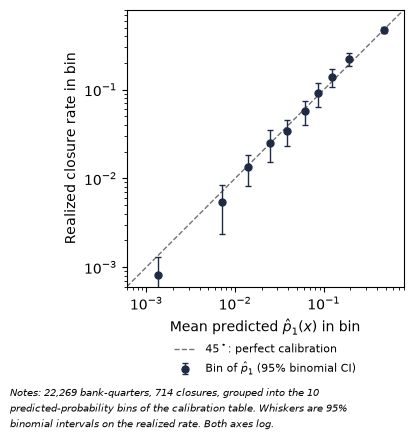

bins whose 95% CI covers the predicted rate: 9/10


In [18]:
# --- 2.3  calibration: does the fitted CCP match realized closure rates?
_E = np.array([0, .005, .01, .02, .03, .05, .075, .10, .15, .25, 1.0])
_b = np.clip(np.digitize(p1, _E[1:-1]), 0, len(_E) - 2)
_n    = np.array([(_b == k).sum() for k in range(len(_E) - 1)])
_pred = np.array([p1[_b == k].mean() for k in range(len(_E) - 1)])
_act  = np.array([y_ccp[_b == k].mean() for k in range(len(_E) - 1)])
_se   = np.sqrt(_act * (1 - _act) / _n)

fig, ax = plt.subplots(figsize=(4.6, 4.4))
fig.subplots_adjust(left=.16, right=.97, top=.97, bottom=.34)
_lim = (6e-4, .8)
ax.plot(_lim, _lim, ls="--", lw=1.0, color=".45", zorder=1,
        label="45$^\\circ$: perfect calibration")
ax.errorbar(_pred, _act, yerr=1.96 * _se, fmt="o", ms=5, color="#1F2A44", ecolor="#1F2A44",
            elinewidth=1.0, capsize=2.5, zorder=3, label="Bin of $\\hat p_1$ (95% binomial CI)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(*_lim); ax.set_ylim(*_lim); ax.set_aspect("equal")
ax.set_xlabel(r"Mean predicted $\hat p_1(x)$ in bin")
ax.set_ylabel("Realized closure rate in bin")
ax.legend(loc="upper center", bbox_to_anchor=(.5, -.17), ncol=1, frameon=False, fontsize=8)
fig.text(.01, .01, f"Notes: {len(p1):,} bank-quarters, {int(y_ccp.sum())} closures, grouped into "
         "the 10\npredicted-probability bins of the calibration table. Whiskers are 95%\n"
         "binomial intervals on the realized rate. Both axes log.",
         fontsize=7.5, style="italic", va="bottom", linespacing=1.5)
plt.show()
print(f"bins whose 95% CI covers the predicted rate: "
      f"{np.sum(np.abs(_act - _pred) <= 1.96 * _se)}/{len(_n)}")

### 2.4  Step 2-1 — Forward simulation

Recall, we drived the following equation from section 1.2, which is the basis of the GMM estimation:
$$\begin{equation}
\boxed{\;\sigma \log \frac{p_0(x_{it})}{p_1(x_{it})} \;=\; \beta \mathbb{E}\big[-\sigma \log p_1^{(1)}(x_{0it}) - c^{(1)}(x_{0it})\big] + c(x_{it})\;}\end{equation}$$

**This step has no dependent variable and no regression.** It computes the **three expectations** the
moment needs, none of which has a closed form:

$$\mathbb{E}\big[\ln p_1(x')\mid x\big], \qquad \mathbb{E}\big[MC(x')\mid x\big], \qquad \mathbb{E}\big[(\log A')^2\mid x\big]$$

where:

- **inputs** — the §2.3 sample and its fitted CCP, plus the supplied `EX` (the centre of $x'$),
  `POOLS` (the innovations to resample) and `HN`/`SN` (next period's Congress).
- **output** — three columns of length 22,269, consumed directly by §2.5.

In [19]:
def forward_simulate(sample, ccp_fit, supplied, R=CFG.R_FORWARD, seed=CFG.SEED):
    """Step 2-1  The expectations that bring the unobserved future into the moment.

    Arguments come in three bundles, so the call reads as "this sample, this fitted CCP,
    these supplied inputs":
      sample    the §2.3 CCP sample (one row per bank-quarter)
      ccp_fit   dict(knots, gamma, c0) — the basis knots and the fitted §2.3 logit
      supplied  dict(MCV, B_MC, S_MC, POOLS, EX, HN, SN) — the supplied inputs declared at the top of §2

    For each of R draws: x'_s = E[x'|x] + a resampled innovation; floor the two ratios
    that cannot go negative; evaluate the CCP at x' (with the shifted design) and the
    Tobit cost at x'; accumulate.

    Returns dict(Eln_p_next, Emc_next, Ela2) = (E[ln p1'|x], E[MC'|x], E[(log A')^2|x]).
    Pass it straight to the moment assembly in §2.5.

    Four conventions that are not optional:
      * ln p' is averaged, never log(average p') — the moment needs E[ln p'].
      * next period's Congress is HN/SN, not today's house/senate.
      * Ela2 is the second moment of the SIMULATED log_assets STATE: average
        cur["log_assets"] ** 2 over draws.  It must be simulated, not (E[log_assets'])^2 —
        the gap is a Jensen term.  It is NOT log(asset level)^2: `log_assets` and `assets`
        are two SEPARATE draws (EX/POOLS["log_assets"] vs EX/POOLS["assets"]), so squaring
        the log of the asset level silently inflates sigma by a factor of ~3.
      * MC is fitted as cost/assets, so E[MC'|x] = expected_y(x'b, S_MC) * A_next, where the
        asset LEVEL A_next is drawn separately: EX["assets"] + a POOLS["assets"]
        innovation.  The level `assets` is not one of the six state variables in SPL.
    """
    rng = np.random.default_rng(seed)
    knots, gamma, c0 = ccp_fit["knots"], ccp_fit["gamma"], ccp_fit["c0"]
    EX, POOLS, HN, SN = (supplied["EX"], supplied["POOLS"],
                         supplied["HN"], supplied["SN"])
    MCV, B_MC, S_MC = supplied["MCV"], supplied["B_MC"], supplied["S_MC"]
    n = len(sample)
    lnp = np.zeros(n)
    mcn = np.zeros(n)
    la2 = np.zeros(n)
    for _ in range(R):
        cur = {v: EX[v] + rng.choice(POOLS[v], n) for v in SPL}
        cur["npf_a"] = np.maximum(cur["npf_a"], 0.0)
        cur["realest_a"] = np.maximum(cur["realest_a"], 0.0)
        cur["unemp"] = EX["unemp"] + rng.choice(POOLS["unemp"], n)
        cur["house"], cur["senate"] = HN, SN
        lnp += -np.logaddexp(0.0, -(build_ccp_design(sample, knots, cur) @ gamma + c0))
        a_next = EX["assets"] + rng.choice(POOLS["assets"], n)
        xb = B_MC[0] + sum(B_MC[i + 1] * cur[v] for i, v in enumerate(MCV))
        mcn += expected_y(xb, S_MC) * a_next               # noqa: F821 (expected_y is in §2.1)
        la2 += cur["log_assets"] ** 2
    return {"Eln_p_next": lnp / R, "Emc_next": mcn / R, "Ela2": la2 / R}

In [20]:
# the fitted CCP travels as one bundle, so forward_simulate takes 5 arguments, not 13
ccp_fit = dict(knots=KNOTS, gamma=gamma, c0=c0)

t0 = time.time()
exp = forward_simulate(smp, ccp_fit, SUPPLIED, R=CFG.R_FORWARD, seed=CFG.SEED)
print(f"R={CFG.R_FORWARD} draws in {time.time()-t0:.1f}s\n")

R=5000 draws in 150.8s



In [21]:
# --- given: does your second stage reproduce the authors' columns?
#
# The test is RELATIVE L1 error, not correlation.  These columns are so nearly collinear
# with the authors' that correlation cannot grade them: writing Ela2 as log(E[A'])^2 -- the
# log of the expected asset LEVEL -- instead of E[(log A')^2] still scores corr = 0.9997
# while inflating sigma roughly threefold.  On relative L1 that bug scores 0.0031 against a
# correct answer's 0.00017, which is why the Ela2 tolerance is 0.002: 12x above a correct
# answer and 1.5x below the bug.  (Re-measured at R=5000, seed 42.)
#
# Known limit: (E[log A'])^2, the square of the MEAN rather than the mean of the square,
# scores 0.00017 too and this gate cannot separate it.  It is harmless downstream.
_TOL  = {"Eln_p_next": 0.02, "Emc_next": 0.03, "Ela2": 0.002}
_HINT = {
    "Eln_p_next": "the LAG SHIFT in build_ccp_design -- next period's first lag slot must be "
                  "TODAY'S VALUE, not today's first lag.",
    "Emc_next":   "the rescale -- E[MC'|x] = expected_y(x'b, S_MC) * A_next, where A_next is a "
                  "SEPARATE draw EX['assets'] + POOLS['assets'].",
    "Ela2":       "Ela2 must be the second moment of the simulated log_assets STATE "
                  "(mean of cur['log_assets']**2), NOT log(asset level)**2 -- different draws.",
}
_rows, _bad = {}, []
for _n, _k, _ref in [("E[ln p1'|x]",  "Eln_p_next", _param["Eln_prob_next"].to_numpy()),
                     ("E[MC'|x]",     "Emc_next",   _param["Emc_next"].to_numpy()),
                     ("E[(logA')^2]", "Ela2",       _param["Elogasset_next2"].to_numpy())]:
    _o, _r = exp[_k], _ref.astype(float)
    _rel = np.abs(_o - _r).mean() / np.abs(_r).mean()
    # NaN-safe: a bug that puts NaN in the column (e.g. log() of a negative simulated asset
    # level) makes _rel nan, and `nan >= tol` is False -- which would print "within tolerance".
    if not np.isfinite(_rel) or _rel >= _TOL[_k]:
        _bad.append(_k)
    _rows[_n] = {"rel L1 err": _rel, "tolerance": _TOL[_k],
                 "corr": np.corrcoef(_o, _r)[0, 1],
                 "": "OK" if (np.isfinite(_rel) and _rel < _TOL[_k]) else "BAD"}
for _k in _bad:
    print(f"{_k} is off. The usual cause is {_HINT[_k]}")
print("all three within tolerance." if not _bad else "")
display(pd.DataFrame(_rows).T)

all three within tolerance.


,rel L1 err,tolerance,corr,
E[ln p1'|x],0.014213,0.02,0.997631,OK
E[MC'|x],0.004106,0.03,0.999996,OK
E[(logA')^2],0.00017,0.002,0.999999,OK


### 2.5  Step 2-2 — GMM

**Object.** $(\sigma,\ \theta_{nmc})$ — the nine structural parameters, with $\beta$ calibrated.

$$g_{it} \;:=\; \underbrace{\sigma\Big[\log\tfrac{p_0}{p_1} + \beta\,\mathbb{E}[\ln p_1']\Big]}_{\text{column 1 of } C} \;+\; \underbrace{\big[\tilde x - \beta\,\mathbb{E}[\tilde x']\big]'\theta}_{\text{columns 2--9 of } C} \;+\; \underbrace{\beta\,\mathbb{E}[MC'] - MC}_{d_0}, \qquad \mathbb{E}[Z\,g] = 0$$

where:

- $\tilde x = [\,1,\ \log A,\ (\log A)^2,\ npf,\ roa,\ realest,\ house,\ senate\,]$, evaluated
  today and — through §2.4 — next period.
- $Z$ — the 8 terms of $\tilde x$, plus the three state variables **excluded** from $\tilde x$ --
  `equity_a`, `asset_growth_1y`, `unemp`.

Two-step GMM is that solve twice: at $W = Z'Z/N$, then at the efficient $W = Z'gg'Z/N$.

**Compare with KLW Table 7:**

![KLW Table 7](https://raw.githubusercontent.com/mhnam/dse2026-practicum/main/practicum1-bank-closure/docs/table7.png)

**Bottom line.** The CCP, the transitions and the structural parameters all replicate on this
panel. Table 3 is the documented casualty: a missing estimation file in the authors' own
package, which §2.6 shows is enough to break the second stage.

<details>
<summary>▸ Where $\sigma$ comes from.</summary>
 Those three exclusions. Without at least one variable that shifts
behaviour but is absent from $\tilde x$, the moment is satisfied by $\sigma = 0$ and the model
degenerates.
</details>

<details>
<summary>▸ Why instruments at all.</summary>
 The equation holds exactly at the *true* CCP; with the estimated
$\hat p_1$ it holds only in expectation, so the residual is projected on $Z$ rather than solved
row by row.
</details>

<details>
<summary>▸ The printed $\theta$ has the opposite sign to Table 7</summary>

The code stores $c = MC - \tilde x'\theta$ (§1.1), so a term that *raises* the cost of closing
prints as negative. Table 7's House $= +829$ means one extra banking-committee member from the
bank's state makes closing it about \$0.83M **more** costly, so the bank is **less** likely to be
closed; the same term prints here as $-829$.

$$\underbrace{c(x)}_{\text{unchanged}} \;=\; MC(x) \;-\; \tilde x'\underbrace{\theta_{\text{code}}}_{-829} \;=\; MC(x) \;+\; \tilde x'\underbrace{\theta_{\text{paper}}}_{+829}$$

Only $\theta$ flips; $\beta$ and $\sigma$ are stored as the paper reports them. Read your own
output by asking what a term does to the *cost of closing*: raising it protects the bank,
lowering it hastens closure.

</details>

<details>
<summary>▸ What this replicates.</summary>
 σ lands within a few percent of the published 639.8
and every θ sign is correct — from **your** CCP and **your** forward simulation, not the
authors'. The J-statistic does not reject at 5%, so the eleven instruments are consistent with
the model's own restrictions.
</details>

In [22]:
# --- 2.5  assemble the moment, estimate, report
# the NMC index x_tilde, evaluated now and next period
THETA_LABELS = ["const", "log_assets", "log_assets^2", "npf_a", "roa",
                "realest_a", "House", "Senate"]

_n, _one = len(smp), np.ones(len(smp))
_g  = lambda v: smp[v].to_numpy(float)
_la = _g("log_assets")
X_now  = np.column_stack([_one, _la, _la**2, _g("npf_a"), _g("roa"),
                          _g("realest_a"), _g("house"), _g("senate")])
X_next = np.column_stack([_one, EX["log_assets"], exp["Ela2"],
                          np.maximum(EX["npf_a"], 0.0), EX["roa"],
                          np.maximum(EX["realest_a"], 0.0), HN, SN])
# 11 instruments: the 8 NMC terms plus the three EXCLUDED state variables
# (equity, asset growth, unemp) that identify sigma
Z = np.column_stack([_one, _la, _la**2, _g("npf_a"), _g("roa"), _g("house"), _g("senate"),
                     _g("equity_a"), _g("realest_a"), _g("asset_growth_1y"), _g("unemp")])

# today's monetary cost, on the same cost/assets rescale forward_simulate applies to MC'
_xb_now = B_MC[0] + sum(B_MC[i+1] * _g(v) for i, v in enumerate(MCV))
mc_now  = expected_y(_xb_now, S_MC) * _g("assets")
# log(p0/p1) is -inf wherever p1 == 1; it never happens here (max p1 = 0.99999999)
p_now   = np.clip(p1, None, 1.0 - 1e-9)

# g = C c + d0, with c = [sigma, *theta].  Linear in every parameter.
_lo = np.log1p(-p_now) - np.log(p_now)                       # log(p0/p1)
C   = np.column_stack([_lo + PAPER_BETA * exp["Eln_p_next"],  # multiplies sigma
                       X_now - PAPER_BETA * X_next])          # multiplies theta
d0  = PAPER_BETA * exp["Emc_next"] - mc_now

In [23]:
# The residual is linear in every structural parameter, so two-step GMM is a
# weighted linear-IV solve; no nonlinear optimizer or starting value is needed.
gmm = gmm_fit(C, d0, Z, maxiter=2)

sigma_hat, theta_hat = float(gmm.params[0]), gmm.params[1:]
_J, _pJ, _dof = gmm.jtest()

# the markdown's overidentification claim, printed rather than asserted:
# 11 instruments - 9 parameters = 2 degrees of freedom.
print(f"J = {_J:.2f} on {_dof} d.f.,  p = {_pJ:.3f}"
      f"  ({'does not reject' if _pJ > .05 else 'REJECTS'} at 5%)")

pd.DataFrame({"estimate": gmm.params, "se": gmm.bse},
             index=["sigma"] + THETA_LABELS).round(3)

J = 1.05 on 2 d.f.,  p = 0.592  (does not reject at 5%)


,estimate,se
sigma,681.459,130.522
const,-492682.347,53981.015
log_assets,90936.431,9653.084
log_assets^2,-4201.182,427.445
npf_a,-52509.674,11600.628
roa,-54752.089,11018.400
realest_a,-190503.568,38771.834
House,-835.019,117.498
Senate,223.469,97.452


### 2.6  Which variable enters which model

| variable | MC §2.1 (Tobit) | state §2.2 (VAR) | CCP §2.3 (logit) | $\tilde x$ NMC §2.5 | $Z$ §2.5 | S1 MC | S2 MC | S3 NMC ($\tilde x$) |
|---|--|---|---|---------------------|---|---|---|---------------------|
| `const` | ✓ | const | intercept | ✓                   | ✓ | ✓ | ✓ | ✓                   |
| `log_assets` | ✓ | dep + L0–L3 | spline ×4 | ✓                   | ✓ | ✓ | ✓ | ✓                   |
| `log_assets^2` | | | | ✓                   | ✓ | | | ✓                   |
| `equity_a` | ✓ | dep + L0–L3 | spline ×4 |                     | ★ | ✓ | ✓ |                     |
| `npf_a` | ✓ | dep + L0–L3 | spline ×4 | ✓                   | ✓ | ✓ | ✓ | ✓                   |
| `npf_a^2` | | | |                    |  | | **NEW** |                     |
| `roa` | ✓ | dep + L0–L3 | spline ×4 | ✓                   | ✓ | | | ✓                   |
| `realest_a` | ✓ | dep + L0–L3 | spline ×4 | ✓                   | ✓ | ✓ | ✓ | ✓                   |
| `asset_growth_1y` | | dep + L0–L3 | spline ×4 |                    | ★ | | |                     |
| `unemp` | | exog L0–L3 | linear ×4 |                    | ★ | **NEW** | ✓ |                     |
| `house` | | | linear | ✓                   | ✓ | | | ✓                   |
| `senate` | | | linear | ✓                   | ✓ | | | ✓                   |
| `trend` | | | |                    |  | | | **NEW**             |

$$c(x) = MC(x) - \tilde x'\theta$$

★ in the $Z$ column marks the three state variables that are instruments but are **absent from $\tilde x$**. They are what identifies $\sigma$: without a variable that shifts behaviour and does not enter the index, the moment is satisfied by $\sigma = 0$.

**The last three columns are your assignment.** They are the panels `set_S1`, `set_S2` and
`set_S3` on Kaggle, each generated from a **richer** model than the one you just estimated, and
the revisions are **cumulative** — S2 carries S1's change plus its own, S3 carries both plus a
third. This notebook does not walk through them; the table is here so you can see exactly which
variable belongs in which step before you start.

| panel | what is different | which step you revise |
|---|---|---|
| **S1** | the monetary cost also depends on the **state unemployment rate** | §2.1 — the variable list |
| **S2** | S1, **and** resolution cost is **convex in bad loans** (`npf_a^2`) | §2.1 — the functional form |
| **S3** | S2, **and** the regulator gets **steadily tougher over time** (`trend`) | §2.5 — the NMC index |

Their monetary-cost baseline is `const, log_assets, equity_a, npf_a, realest_a` — **not** §2.1's
six-variable Tobit design. That is why `roa` and `unemp` are absent from it, and why S1's
`unemp` counts as **NEW** even though §2.1 already estimates it on the real panel.

---
## 3  Counterfactuals

### 3.1  What a counterfactual is

§2 recovered $\hat\sigma$ and $\hat\theta$ — the cost function that rationalises what the FDIC
actually did. A **counterfactual** asks a different question: *had one piece of the model been
different, how would the FDIC have behaved?*

The point is that we do **not** hold the closure rule fixed and re-evaluate it at new numbers.
We change one primitive and **re-solve §1's problem**:

$$V(x_{it}) \;=\; \max_{d_{it}\in\{0,1\}} u_{d_{it}}(x_{it}) \;+\; \beta\,\mathbb{E}\big[V(x_{i,t+1}) \mid x_{it},\, d_{it}\big]$$

Change $c(\cdot)$ or $\beta$ and the FDIC closes at different states; that changes the
continuation value $\mathbb{E}[V(x_{i,t+1})]$; which changes where it closes again. The new
closure probabilities are the **fixed point** of that loop, not a re-reading of the old ones.

**How it is solved — not by value function iteration.** The value function never appears. §1's
Hotz–Miller inversion writes it in terms of the CCP itself, $\bar V(x) = -c(x) - \sigma \log p_1(x)$,
which collapses the whole model to a fixed point in $p_1$ alone:

$$\log \frac{p_1(x)}{1-p_1(x)} \;=\; -\frac{1}{\sigma}\Big(c(x) \;+\; \beta\,\mathbb{E}\big[\,-c(x') - \sigma \log p_1(x') \,\big|\, x\,\big]\Big)$$

`solve_ccp` starts from a guess for $p_1$, evaluates the right-hand side by Monte Carlo over
simulated next states, least-squares projects the resulting log-odds back onto the CCP basis,
and repeats. It contracts at rate $\beta$, so 150 iterations on a 6,000-row subsample is the
entire computation — seconds, against the hours a grid-based value function iteration would
need on a 7-dimensional continuous state.

### 3.2  The outcome we report

From §1, $p_1(x_{it})$ is the probability the FDIC closes bank $i$ in state $x_{it}$. Add it up
over every bank-quarter in the panel:

$$\sum_i p_1(x_i) \;=\; \text{the number of closures the model expects on this panel.}$$

It is a sum of *probabilities*, not a count of observed failures — a bank-quarter with
$p_1 = 0.03$ contributes $0.03$. Solve the model twice, once as estimated and once with the
primitive changed, and compare the two totals:

$$\Delta\% \;=\; 100 \times \frac{\sum_i p_1^{\text{cf}}(x_i) \;-\; \sum_i p_1^{\text{base}}(x_i)}{\sum_i p_1^{\text{base}}(x_i)}$$

$\Delta\% = +25$ means the change would have produced 25% **more** closures; $-25$, a quarter
fewer. One number per scenario — that is the entire output.

### 3.3  The three scenarios

Each changes exactly one thing and leaves everything else at its estimated value.

| scenario | the question it asks | what changes |
|---|---|---|
| `no_political` | did congressional oversight hold closures back? | $\theta_{\text{House}} = \theta_{\text{Senate}} = 0$ in $\tilde x'\theta$ |
| `myopic` | what is the option of waiting worth? | $\beta: 0.9582 \to 0$ |
| `npl_stress` | what if every loan book deteriorated? | $\texttt{npf\_a}_i \to \texttt{npf\_a}_i + 0.02$, every bank |

The first two change a **parameter** of the model. The third changes the **state** every bank
sits in — a supervisory stress test — and then re-solves at that shifted state.

### 3.4  Running them

`counterfactual(model, scenario)` takes a **fitted model**, not a data frame: all four
primitives — $MC(x)$, $\tilde x'\theta$, $\beta$ and $f(x'\mid x)$ — enter the fixed point
together, so they have to travel as one object.

`reference_model("replication")` hands you one, which is why the cell below is a single call.
It is **not** your §2 fit. For the simulated `replication` panel it packages:

| field | the primitive | where it comes from |
|---|---|---|
| `cost_coef` | $MC(x)$ | OLS on that panel's resolved banks |
| `trans` | $f(x'\mid x)$, as (const, $\rho$, innovation variance) | one AR(1) per state variable |
| `sigma`, `theta` | $\sigma$ and the index $\tilde x'\theta$ | the published values in `refcheck.json` |
| `beta` | $\beta$ | calibrated, as everywhere else |

**Why not the estimates you just produced in §2?** The solver simulates the state forward, so it
needs a **Markov** state and a transition it can iterate one step at a time. §2's state is a
four-quarter history fitted by VAR(4), and the real panel carries no `trend` column that the CCP
basis expects. The `replication` panel is simulated from the paper's own specification and is
Markov by construction.

For the Kaggle assignment you build **the same object out of your own estimates** on S1/S2/S3 —
the same five fields, your numbers — and hand it to this same function.

In [24]:
# === 3.4  the three counterfactuals ===
# `reference_model` is given: the fitted model for the `replication` panel, assembled from its
# monetary cost, its transitions, and the published sigma and theta.  `seed` fixes the
# Monte-Carlo draws inside the fixed-point solve -- see §3.5.
res_cf = reference_model("replication")

pd.DataFrame({"Δ% expected closures": [counterfactual(res_cf, s, seed=CFG.CF_SEED)
                                       for s in SCENARIOS]}, index=SCENARIOS).round(2)

,Δ% expected closures
no_political,11.54
myopic,92.99
npl_stress,27.88


#### Reading them

**`no_political` +11.5%.** Strip the political terms out of the non-monetary cost and the FDIC
closes about a tenth more banks. Oversight was holding closures back — which is the paper's
whole point — though the magnitude is modest.

**`myopic` +93%.** A regulator that stops valuing the future nearly doubles closures. Waiting
has option value: a distressed bank may recover, and closing forecloses that. Treat this one
with the most caution — $\beta$ is calibrated rather than estimated, and §3.5 shows it is also
the noisiest.

**`npl_stress` +27.9%.** A 2pp deterioration in loan books raises expected closures by roughly
a quarter. Note this is a re-solve: the shock moves the state, the state moves the continuation
value, and the closure rule moves with it.

### 3.5  The same number under different draws

$\Delta\%$ is not a deterministic quantity. The fixed point above is solved by Monte Carlo — the
expectation $\mathbb{E}[\cdot\mid x]$ is an average over simulated next states — so every number
in §3.4 is one draw from a distribution, and `seed` picks which draw.

That matters because **the three scenarios are not equally noisy**, and you cannot tell which is
which by looking at a single run. Change only the seed and see how far each one moves.

In [25]:
# === 3.5  the same counterfactuals under three different seeds ===
_sw = pd.DataFrame({s: [counterfactual(res_cf, s, seed=k) for k in CFG.SEED_SWEEP]
                    for s in SCENARIOS}, index=[f"seed {k}" for k in CFG.SEED_SWEEP])
_sw.loc["spread (max-min)"] = (_sw.iloc[:len(CFG.SEED_SWEEP)].max()
                               - _sw.iloc[:len(CFG.SEED_SWEEP)].min())
_sw.round(2)

,no_political,myopic,npl_stress
seed 0,11.42,106.08,27.85
seed 1,11.44,98.07,27.79
seed 7,11.54,92.99,27.88
spread (max-min),0.12,13.10,0.09


`myopic` moves by about **13 percentage points** across three seeds; the other two move by
about 0.1. That spread is **simulation error, not economics**, and it is avoidable: average
over seeds, or raise `R` in the call, until it is small next to whatever else you are uncertain
about. Report a counterfactual without checking this and you are reporting your random number
generator.